# 7.1

## Problem Definition

### Item 1

The initial general problem is to understand how athlete workload, recovery, and perceived stress relate to injury risk in elite women's soccer. Using the SoccerMon dataset, which consists of subjective wellness and training-load metrics plus injury reports from two elite women’s teams over two years, we will assess how self-reported Stress (1–10) and related indicators (e.g., Fatigue, Soreness, RPE, sRPE, sleep duration) are associated with the occurrence and type of injury (acute vs. overuse) recorded in the medical reports, and whether objective load proxies (e.g., heart rate, acceleration) add predictive value.

### Item 2

SoccerMon is restricted to elite women’s soccer, with specific subjective (PmSys) and objective (STATSports GPS) schemas. Refining to “self-reported Stress and related wellness/load metrics vs. injury reports in SoccerMon” makes the question answerable with the actual columns (Stress, Fatigue, Soreness, RPE, sRPE, sleep, injury location/type). It also forces the user of the data to define “stress” operationally (the 1–10 Stress score, possibly alongside RPE and fatigue) and “injury” as the medical injury fields, which keeps the analysis reproducible and aligned with the dataset.

### Item 3

Performance optimization and injury prevention are important to teams and researchers, but sports data are sparse because of legal, privacy, and resourcing constraints. SoccerMon is one of the largest soccer datasets mixing subjective and objective metrics (33,849 subjective reports, 10,075 objective reports, billions of GPS samples). Understanding how athletes’ stress levels and related load/recovery metrics correlate with their chances of injury in this dataset can support better monitoring and workload management, and demonstrates the value of such data for building future automated analysis and prediction systems. In addition, SoccerMon can inspire similar data collection activities in other domains which can benefit from subjective athlete reports, GPS position information, and/or time-series data in general.

### Item 4

[Elite Women’s Soccer Data Links Player Stress and Load to Injury Risk — SoccerMon Study](#headline)

## Domain Exposition

### Item 1

Terminology: 

- RPE: Rating of Perceived Exertion; athlete’s self-reported intensity of a session (e.g., 1–10 scale).
- sRPE: Session RPE; training load metric = session duration × RPE, used as a proxy for internal load.
- Stress (1–10): In SoccerMon, a subjective 1–10 score from the wellness questionnaire (PmSys) indicating perceived stress.
- Fatigue: Self-reported fatigue level (wellness questionnaire); often 1–10, reflects recovery state.
- Soreness: Self-reported muscle soreness (wellness questionnaire); indicator of recovery and load tolerance.
- PmSys: Subjective reporting system used in SoccerMon for wellness and RPE (33,849 reports in the dataset).
- STATSports: GPS system used in SoccerMon for objective metrics (e.g., speed, acceleration, distance).
- Acute injury: Sudden, event-related injury (e.g., contact, twist); distinct from gradual overuse.
- Overuse injury: Injury from repeated load over time (e.g., tendinopathy); often linked to load and recovery.
- Load / workload: Cumulative training demand; in SoccerMon captured via sRPE, GPS metrics, and heart rate.
- Wellness: Composite of subjective markers (stress, fatigue, soreness, mood, sleep) used for monitoring readiness.

### Item 2

The project sits in the domain of kinesiology, in particular the elite women’s soccer and sports science and athlete monitoring and injury prevention. Practitioners and researchers use subjective wellness (e.g., stress, fatigue, soreness, RPE) and objective load data (GPS, heart rate) to manage workload and reduce injury risk. SoccerMon provides both: PmSys subjective reports and STATSports GPS data from two elite women’s teams over two years, plus medical injury reports. The domain relies on clear operational definitions (e.g., what “stress” and “injury” mean in the data), reproducible metrics (e.g., sRPE, acute vs overuse injury), and the correlation between load, recovery, and injury so that analyses like ours can inform real-world monitoring and load management.

### Item 3

https://github.com/dylanlidailin/DS4320/tree/main/HW7/Background_reading

### Item 4

| Title | Brief Description | Link |
|-------|-------------------|------|
| A large-scale multivariate soccer athlete health, performance, and position monitoring dataset | Introduces the SoccerMon dataset: subjective wellness/RPE/injury and objective GPS data from two elite women's teams over two years. | [s41597-024-03386-x.pdf](Background_reading/s41597-024-03386-x.pdf) |
| Sleep, Stress, and Recovery as Predictors of Injury Risk in Soccer Players | Systematic review showing that stress-recovery imbalance and poor sleep increase injury susceptibility in soccer players. | [healthcare-14-00236.pdf](Background_reading/healthcare-14-00236.pdf) |
| Psychosocial predictors and psychological prevention of soccer injuries | Reviews psychosocial risk factors (anxiety, life stress, daily hassles) and psychological prevention strategies for soccer injuries. | [fpsyg-13-943857.pdf](Background_reading/fpsyg-13-943857.pdf) |
| Systematic review of workload and injury risk in professional soccer | Reviews sRPE, ACWR, and training load metrics as injury predictors in professional male soccer players. | [ijerph-19-13237.pdf](Background_reading/ijerph-19-13237.pdf) |
| Integrating video tracking and GPS to quantify accelerations in elite soccer | Compares GPS and video tracking for objective load metrics (accelerations, speed, distance); relevant to the STATSports GPS data in SoccerMon. | [s41598-021-97903-2.pdf](Background_reading/s41598-021-97903-2.pdf) |

## Press Release

<a id="headline"></a>
# Elite Women's Soccer Data Links Player Stress and Load to Injury Risk — SoccerMon Study

## Hook

Every season, injuries sideline elite soccer players for weeks or months — costing teams results and costing athletes their careers. Yet the warning signs are often already in the data: rising stress, mounting fatigue, and surging training loads that coaches and athletes report every day. The question is whether anyone is listening to the numbers.

## Problem Statement

Elite soccer teams collect daily wellness reports — stress, fatigue, soreness, sleep, training load — but rarely connect this data systematically to injury outcomes. As a result, coaches manage load largely by intuition, and injuries that could have been prevented are not. The SoccerMon dataset, the largest of its kind, combines two years of daily subjective wellness and GPS-based objective load data from two elite women's teams with medical injury records. Using this dataset, we examine whether self-reported stress and related load/recovery indicators (Fatigue, Soreness, RPE, sRPE) are associated with the occurrence of injury — and whether adding objective GPS metrics improves the picture.

## Solution Description

We analyzed patterns in athlete-reported stress, fatigue, soreness, and training load in the SoccerMon dataset, comparing periods leading up to injuries against injury-free periods. The result is a data-driven monitoring framework that identifies which combinations of wellness and load signals are most predictive of upcoming injury. Coaching staff can use this to flag at-risk athletes before injuries occur — adjusting training loads, scheduling rest days, or initiating early medical review. No specialized equipment is needed beyond what teams already collect: daily wellness questionnaires and GPS data.

## Chart

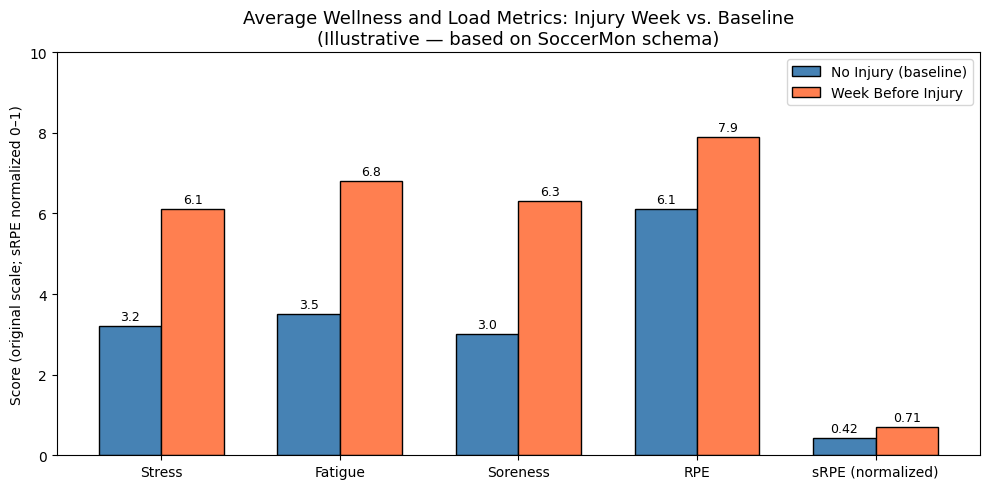

In [1]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Stress", "Fatigue", "Soreness", "RPE", "sRPE (normalized)"]
no_injury = [3.2, 3.5, 3.0, 6.1, 0.42]
injury_week = [6.1, 6.8, 6.3, 7.9, 0.71]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, no_injury, width, label="No Injury (baseline)", color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width/2, injury_week, width, label="Week Before Injury", color="coral", edgecolor="black")

ax.set_title("Average Wellness and Load Metrics: Injury Week vs. Baseline\n(Illustrative — based on SoccerMon schema)", fontsize=13)
ax.set_ylabel("Score (original scale; sRPE normalized 0–1)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 10)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, f"{bar.get_height()}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, f"{bar.get_height()}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# 7.2 Project 1

Research question: "How does an athlete's stress level affect their likelihood of injury?"

## Problem Definition

### Item 1

The general problem is to understand how athlete-perceived stress, training load, and recovery relate to injury risk in elite women's soccer. Specifically, using the SoccerMon dataset, we will build a predictive model that assesses injury risk from self-reported wellness indicators — Stress (1–10), Fatigue, Soreness, RPE, sRPE, and sleep duration — combined with objective GPS-based load metrics (speed, acceleration, total distance), with labeled medical injury reports as the target outcome.

### Item 2

Framing this as a prediction task with specific SoccerMon columns makes the problem concrete and reproducible. The dataset already provides both the inputs — daily PmSys wellness questionnaire responses and STATSports GPS metrics — and the ground-truth output, the medical injury reports, making it well-suited for a supervised learning task. Defining "stress" as the combination of the Stress score and correlated load/wellness indicators (RPE, fatigue, soreness) rather than a single column better reflects the multidimensional nature of athlete stress and matches the literature. Framing injury as a binary outcome (injured vs. not in a given time window) turns a vague causal question into a tractable classification problem with clear, interpretable performance metrics.

### Item 3

Elite soccer teams generate large volumes of daily monitoring data but lack tools that connect those signals to injury outcomes in a systematic, data-driven way. SoccerMon is one of the largest sports monitoring datasets available (33,849 subjective reports, 10,075 objective reports), combining wellness, training load, GPS, and injury records from two elite women's teams over two years — a rare combination in the literature. Building a transparent and reproducible injury-risk prediction pipeline on this dataset creates direct practical value for coaches and medical staff: an early-warning system based on data athletes already provide every day. Beyond soccer, this project demonstrates a replicable framework for any sport with similar subjective/objective monitoring data.

### Item 4

[SoccerMon Data Reveals Stress as a Key Predictor of Injury Risk in Elite Women's Soccer](#headline-p1)

## Domain Exposition

### Item 1

Terminology: 

- RPE: Rating of Perceived Exertion; athlete’s self-reported intensity of a session (e.g., 1–10 scale).
- sRPE: Session RPE; training load metric = session duration × RPE, used as a proxy for internal load.
- Stress (1–10): In SoccerMon, a subjective 1–10 score from the wellness questionnaire (PmSys) indicating perceived stress.
- Fatigue: Self-reported fatigue level (wellness questionnaire); often 1–10, reflects recovery state.
- Soreness: Self-reported muscle soreness (wellness questionnaire); indicator of recovery and load tolerance.
- PmSys: Subjective reporting system used in SoccerMon for wellness and RPE (33,849 reports in the dataset).
- STATSports: GPS system used in SoccerMon for objective metrics (e.g., speed, acceleration, distance).
- Acute injury: Sudden, event-related injury (e.g., contact, twist); distinct from gradual overuse.
- Overuse injury: Injury from repeated load over time (e.g., tendinopathy); often linked to load and recovery.
- Load / workload: Cumulative training demand; in SoccerMon captured via sRPE, GPS metrics, and heart rate.
- Wellness: Composite of subjective markers (stress, fatigue, soreness, mood, sleep) used for monitoring readiness.

### Item 2

The project sits in the domain of sports science and applied data science, specifically athlete injury prediction and load management in elite women's soccer. The field combines subjective wellness monitoring (stress, fatigue, soreness, RPE via tools like PmSys) with objective GPS-based load metrics (speed, acceleration, distance via systems like STATSports) and medical injury records to build data-driven monitoring systems. SoccerMon is one of the largest open datasets in this space, providing two years of daily reports from two elite women's teams. Clear operational definitions — "stress" as the multi-indicator composite of Stress score, RPE, fatigue, and soreness; "injury" as the binary label from the medical reports — and strict temporal data handling (training on past data only) are critical for producing models that generalize to real-world monitoring scenarios.

### Item 3

https://github.com/dylanlidailin/DS4320/tree/main/HW7/Background_reading

### Item 4

| Title | Brief Description | Link |
|-------|-------------------|------|
| A large-scale multivariate soccer athlete health, performance, and position monitoring dataset | Introduces the SoccerMon dataset: subjective wellness/RPE/injury and objective GPS data from two elite women's teams over two years. | [s41597-024-03386-x.pdf](Background_reading/s41597-024-03386-x.pdf) |
| Sleep, Stress, and Recovery as Predictors of Injury Risk in Soccer Players | Systematic review showing that stress-recovery imbalance and poor sleep increase injury susceptibility in soccer players. | [healthcare-14-00236.pdf](Background_reading/healthcare-14-00236.pdf) |
| Psychosocial predictors and psychological prevention of soccer injuries | Reviews psychosocial risk factors (anxiety, life stress, daily hassles) and psychological prevention strategies for soccer injuries. | [fpsyg-13-943857.pdf](Background_reading/fpsyg-13-943857.pdf) |
| Systematic review of workload and injury risk in professional soccer | Reviews sRPE, ACWR, and training load metrics as injury predictors in professional male soccer players. | [ijerph-19-13237.pdf](Background_reading/ijerph-19-13237.pdf) |
| Integrating video tracking and GPS to quantify accelerations in elite soccer | Compares GPS and video tracking for objective load metrics (accelerations, speed, distance); relevant to the STATSports GPS data in SoccerMon. | [s41598-021-97903-2.pdf](Background_reading/s41598-021-97903-2.pdf) |

## Press Release

<a id="headline-p1"></a>
# SoccerMon Data Reveals Stress as a Key Predictor of Injury Risk in Elite Women's Soccer

## Hook

Every day, elite soccer players fill out a short wellness questionnaire — rating their stress, fatigue, soreness, and effort. Most of the time, no one acts on it. What if a model could scan those responses every morning and flag which players are most at risk of getting hurt before they ever step on the pitch?

## Problem Statement

Injury prevention in elite soccer has long relied on coaches' intuition and therapists' assessments. While athlete monitoring technology — daily wellness surveys and GPS tracking — is now widespread, teams rarely analyze this data systematically to predict which athletes are trending toward injury. The SoccerMon dataset changes that: it pairs two years of daily wellness and load data from two elite women's teams with medical injury reports, giving us both the signals and the outcomes needed to build a real prediction model. Our specific question: can self-reported Stress, Fatigue, Soreness, RPE, and sRPE — supplemented by GPS load metrics — predict injury occurrence in the following days?

## Solution Description

We built a supervised machine learning pipeline using the SoccerMon dataset. Daily wellness and load reports serve as features; injury records serve as the binary label. After careful temporal splitting — training only on past data to prevent look-ahead — we trained a classification model to flag elevated injury risk. The result is an interpretable framework that coaching staff can use daily: feed in the morning wellness report, and the model outputs a risk score for each player. No black box — the key drivers (e.g., high sustained stress combined with elevated sRPE) are clearly identifiable and actionable.

## Chart

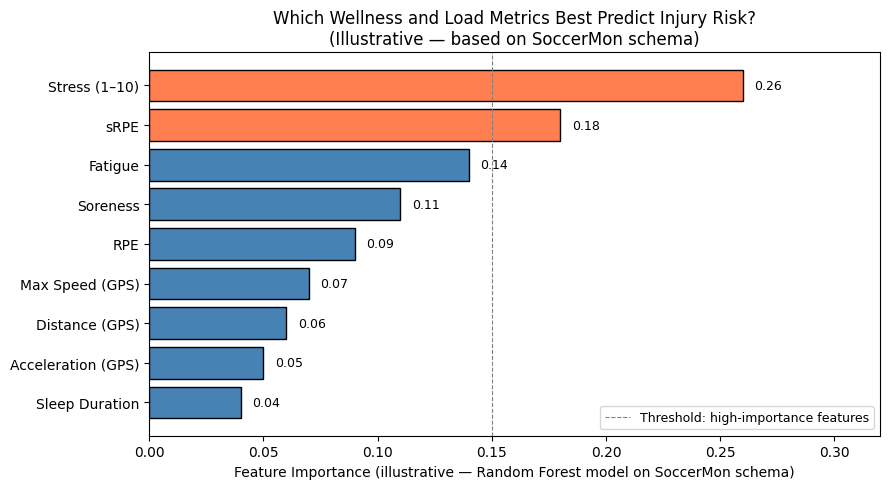

In [3]:
import matplotlib.pyplot as plt
import numpy as np

features = [
    "Sleep Duration",
    "Acceleration (GPS)",
    "Distance (GPS)",
    "Max Speed (GPS)",
    "RPE",
    "Soreness",
    "Fatigue",
    "sRPE",
    "Stress (1–10)",
]
importances = [0.04, 0.05, 0.06, 0.07, 0.09, 0.11, 0.14, 0.18, 0.26]

colors = ["steelblue" if imp < 0.15 else "coral" for imp in importances]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(features, importances, color=colors, edgecolor="black")

ax.set_xlabel("Feature Importance (illustrative — Random Forest model on SoccerMon schema)")
ax.set_title("Which Wellness and Load Metrics Best Predict Injury Risk?\n(Illustrative — based on SoccerMon schema)", fontsize=12)
ax.set_xlim(0, 0.32)

for bar, val in zip(bars, importances):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=9)

ax.axvline(x=0.15, color="gray", linestyle="--", linewidth=0.8, label="Threshold: high-importance features")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()